# Analisis de Percepcion de Complejidad Armonica

**Objetivo:** Entender que metricas jSymbolic explican por que los oyentes perciben
ciertos audios como mas complejos.

**11 features: VMS, VT, VS, VDR, ST, 7C, NSC, CC, DTMCVI, PRTMCVI, VNSPC**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12})

ROOT = Path('..')
ENCUESTA = ROOT / 'Encuesta'
COMP_L = ROOT / 'test4EVO' / 'ComparacionL'
COMP_H = ROOT / 'test4EVO' / 'ComparacionH'

df = pd.read_csv(ENCUESTA / '1.csv', sep=',')
score_map = {
    'A mucho más compleja que B': 2,
    'A más compleja que B': 1,
    'Igual de complejas': 0,
    'B más compleja que A': -1,
    'B mucho más compleja que A': -2
}
C_cols = [c for c in df.columns if c.startswith('C') and c != 'Correos']
L_cols = ['L1','L2','L3','L4','L5','L6']
H_cols = ['H1','H2','H3','H4','H5','H6']
all_cols = L_cols + H_cols

for col in all_cols + C_cols:
    df[col + '_score'] = df[col].map(score_map)

mask = (df['C1_score'] < 0) & (df['C2_score'] < 0)
df_f = df[mask].copy()
print(f'Participantes: {len(df)} total, {len(df_f)} pasaron control')


Participantes: 52 total, 43 pasaron control


## 1. Mapa de audios por comparacion

In [2]:
rvae_files = {
    'L1': ('L1) Cmin-Gmaj-Cmin-Fmin-Cmin.mid',  'M3) Cm-Bb-Ab-Cs-Eb.mid'),
    'L2': ('L4) Cm-C7-Fm-Bb-C.mid',              'M2) Cmin-Gmaj-C7-Fmin-Cmin.mid'),
    'L3': ('L3) Cmin-Gmaj-A7-Fmaj-Cmin.mid',     'M22) Cm-Bb-Bb-Dm7-Eb.mid'),
    'L4': ('L10) Cs-Fsdim7-Fm7-Bb9-F.mid',       'M4) Cmin-Gmaj-Fs7-F7-Cmin.mid'),
    'L5': ('L5) Cmin-Emin-Emin-Fmaj-Cmin.mid',   'M1) Cm-Bb-Bb-Cm7-Fm7.mid'),
    'L6': ('L9) Abmaj7-Cmin7-Csmaj-Ebmaj.mid',   'M6) Cmin-Fsmin-A7-Dsmin-Cmin.mid'),
}
human_files = {
    'H1': ('00001REARM_OG.mid',  '00001REARM_MIO.mid'),
    'H2': ('00002REARM_OG.mid',  '00002REARM_MIO.mid'),
    'H3': ('00003REARM_OG.mid',  '00003REARM_MIO.mid'),
    'H4': ('00004REARM_OG.mid',  '00004REARM_MIO.mid'),
    'H5': ('00005REARM_OG.mid',  '00005REARM_MIO.mid'),
    'H6': ('00006REARM_OG.mid',  '00006REARM_MIO.mid'),
}
def get_labels(col):
    if col in rvae_files:
        return ('RVAE','SCL','L') if int(col[1])%2==1 else ('SCL','RVAE','L')
    else:
        return ('Humano','SCL','H') if int(col[1])%2==1 else ('SCL','Humano','H')
print("Mapping OK")
for sc in all_cols:
    a,b,blk = get_labels(sc)
    print(f"  {sc} [{blk}]: A={a}, B={b}")


Mapping OK
  L1 [L]: A=RVAE, B=SCL
  L2 [L]: A=SCL, B=RVAE
  L3 [L]: A=RVAE, B=SCL
  L4 [L]: A=SCL, B=RVAE
  L5 [L]: A=RVAE, B=SCL
  L6 [L]: A=SCL, B=RVAE
  H1 [H]: A=Humano, B=SCL
  H2 [H]: A=SCL, B=Humano
  H3 [H]: A=Humano, B=SCL
  H4 [H]: A=SCL, B=Humano
  H5 [H]: A=Humano, B=SCL
  H6 [H]: A=SCL, B=Humano


## 2. Dataset de complejidad percibida

In [3]:
complexity_records = []
for col in all_cols:
    sc = col + '_score'
    lab_a, lab_b, blk = get_labels(col)
    for idx in df_f.index:
        v = df_f.loc[idx, sc]
        if pd.isna(v): continue
        complexity_records.append({'p':idx,'col':col,'blk':blk,'audio':lab_a,'compl':v})
        complexity_records.append({'p':idx,'col':col,'blk':blk,'audio':lab_b,'compl':-v})
df_comp = pd.DataFrame(complexity_records)
print(f"Obs: {len(df_comp)}")

# Complejidad promedio por audio
comp_by_audio = (df_comp.groupby(['blk','col','audio'])['compl']
    .agg(['mean','std','count','sem']).reset_index()
    .rename(columns={'mean':'compl_mean','std':'compl_std','count':'n','sem':'compl_se'}))
comp_by_audio = comp_by_audio.sort_values('compl_mean', ascending=False)
print("Ranking de complejidad:")
print(comp_by_audio.to_string(index=False))


Obs: 1032
Ranking de complejidad:
blk col  audio  compl_mean  compl_std  n  compl_se
  H  H3    SCL    0.906977   1.268932 43  0.193510
  H  H5    SCL    0.790698   1.389727 43  0.211931
  L  L5    SCL    0.581395   1.159486 43  0.176820
  L  L6   RVAE    0.465116   1.278929 43  0.195035
  H  H4    SCL    0.395349   1.049706 43  0.160079
  L  L1   RVAE    0.372093   0.976467 43  0.148910
  H  H2    SCL    0.232558   1.231283 43  0.187769
  H  H6 Humano    0.209302   1.081404 43  0.164913
  L  L3   RVAE    0.162791   1.343950 43  0.204950
  H  H1 Humano    0.046512   1.361957 43  0.207697
  L  L2   RVAE    0.023256   1.184993 43  0.180710
  L  L4    SCL    0.023256   1.101695 43  0.168007
  L  L2    SCL   -0.023256   1.184993 43  0.180710
  L  L4   RVAE   -0.023256   1.101695 43  0.168007
  H  H1    SCL   -0.046512   1.361957 43  0.207697
  L  L3    SCL   -0.162791   1.343950 43  0.204950
  H  H6    SCL   -0.209302   1.081404 43  0.164913
  H  H2 Humano   -0.232558   1.231283 43  0.1877

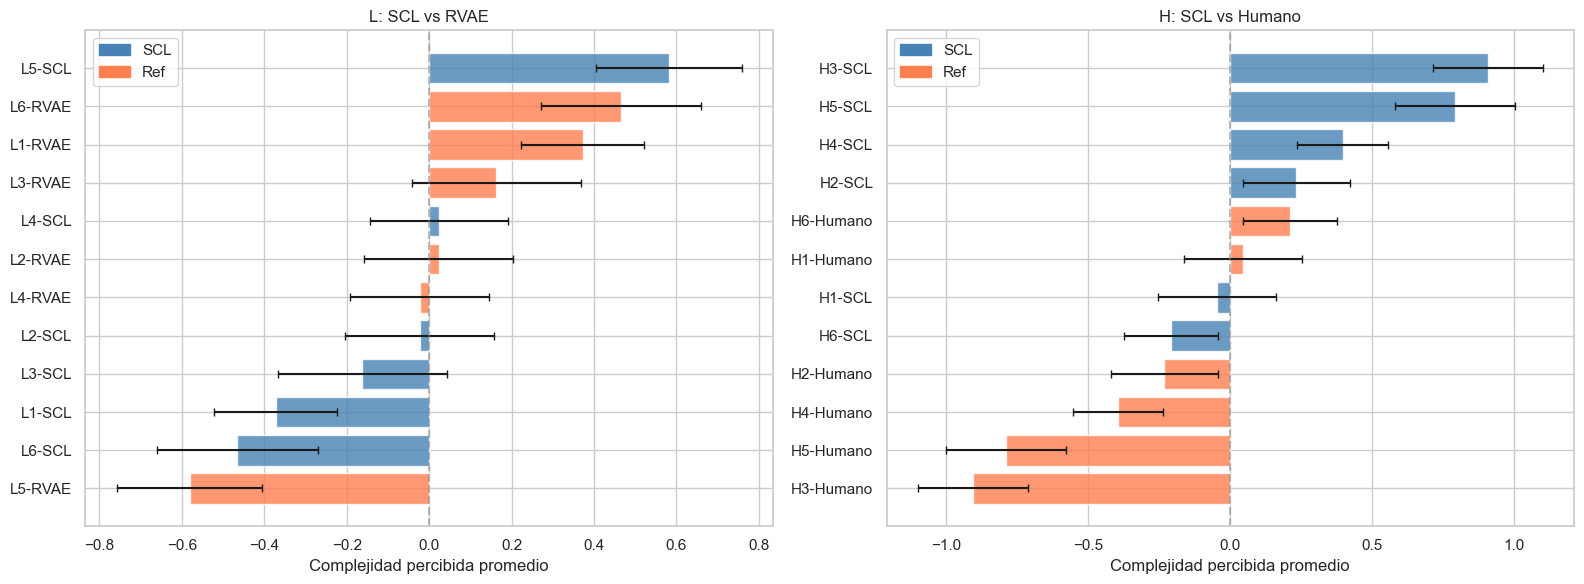

In [4]:
# Ranking visual
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for idx, (blk, title) in enumerate([('L','L: SCL vs RVAE'), ('H','H: SCL vs Humano')]):
    sub = comp_by_audio[comp_by_audio['blk']==blk].sort_values('compl_mean')
    ax = axes[idx]
    colors = ['coral' if ('RVAE' in l or 'Humano' in l) else 'steelblue' for l in sub['audio']]
    ax.barh(range(len(sub)), sub['compl_mean'], xerr=sub['compl_se'], color=colors, alpha=0.8, capsize=3)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([f"{r['col']}-{r['audio']}" for _,r in sub.iterrows()])
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set_xlabel('Complejidad percibida promedio')
    ax.set_title(title)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue',label='SCL'),Patch(color='coral',label='Ref')])
plt.tight_layout(); plt.show()


## 3. Cargar features jSymbolic

In [5]:
feature_names = [
    'Vertical_Minor_Seconds','Vertical_Tritones','Vertical_Sevenths',
    'Vertical_Dissonance_Ratio','Standard_Triads','Seventh_Chords',
    'Non-Standard_Chords','Complex_Chords',
    'Distance_Between_Two_Most_Common_Vertical_Intervals',
    'Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals',
    'Variability_of_Number_of_Simultaneous_Pitch_Classes',
]
LAB = {f:k for f,k in zip(feature_names,
    ['VMS','VT','VS','VDR','ST','7C','NSC','CC','DTMCVI','PRTMCVI','VNSPC'])}

df_L_all = pd.read_csv(COMP_L / '2.csv', index_col=0)
df_L_all.columns = df_L_all.columns.str.strip()
df_L_all.index = df_L_all.index.map(lambda x: Path(str(x).strip()).name)

df_H_all = pd.read_csv(COMP_H / 'datahvsmio_full.csv', index_col=0)
df_H_all.columns = df_H_all.columns.str.strip()
df_H_all.index = df_H_all.index.str.strip()
print(f'L: {df_L_all.shape}, H: {df_H_all.shape}')


L: (12, 183), H: (18, 183)


## 4. Mapear features a cada audio

In [6]:
def get_file(col, audio):
    d = rvae_files if col in rvae_files else human_files
    ref, scl = d[col]
    return scl if audio=='SCL' else ref
def get_df(col):
    return df_L_all if col in rvae_files else df_H_all

rows = []
for _, r in comp_by_audio.iterrows():
    f = get_file(r['col'], r['audio'])
    dfe = get_df(r['col'])
    if f not in dfe.index: continue
    fr = dfe.loc[f]
    vals = {LAB[fn]: pd.to_numeric(fr[fn], errors='coerce') for fn in feature_names}
    vals['compl'] = r['compl_mean']; vals['compl_se'] = r['compl_se']
    vals['col']=r['col']; vals['audio']=r['audio']; vals['blk']=r['blk']; vals['n']=r['n']
    rows.append(vals)

df_feats = pd.DataFrame(rows)
fs = list(LAB.values())
print(f"Audios con features: {len(df_feats)}")
print(df_feats[['col','audio','compl']+fs].to_string())


Audios con features: 24
   col   audio     compl      VMS       VT       VS      VDR      ST      7C     NSC      CC  DTMCVI  PRTMCVI   VNSPC
0   H3     SCL  0.906977  0.02103  0.00000  0.00000  0.29120  0.0000  0.7500  0.2500  0.2500     3.0   0.9725  0.4331
1   H5     SCL  0.790698  0.00000  0.02647  0.00000  0.15890  0.2500  0.5000  0.2500  0.0000     5.0   0.7514  0.4331
2   L5     SCL  0.581395  0.00000  0.00000  0.09524  0.10530  0.6000  0.4000  0.0000  0.0000     4.0   1.0000  0.4900
3   L6    RVAE  0.465116  0.00000  0.00000  0.11110  0.12500  0.5000  0.5000  0.0000  0.0000     4.0   0.8333  0.5001
4   H4     SCL  0.395349  0.00000  0.00000  0.00000  0.13980  0.5000  0.0000  0.5000  0.0000     4.0   0.9939  0.5001
5   L1    RVAE  0.372093  0.00000  0.00000  0.00000  0.00000  1.0000  0.0000  0.0000  0.0000     1.0   1.0000  0.0000
6   H2     SCL  0.232558  0.02545  0.06560  0.02577  0.35010  0.1429  0.4286  0.4286  0.2857     1.0   0.9295  0.6390
7   H6  Humano  0.209302  0.0000

## 5. Correlacion: features vs complejidad percibida

In [7]:
# Global
corrs = []
for f in fs:
    r,p = stats.pearsonr(df_feats[f], df_feats['compl'])
    corrs.append({'Feature':f,'r':round(r,3),'p':round(p,4),'sig':'*' if p<.05 else 'n.s.'})
corr_df = pd.DataFrame(corrs).sort_values('r', ascending=False)
print("Correlacion global features vs complejidad:")
print(corr_df.to_string(index=False))


Correlacion global features vs complejidad:
Feature      r      p  sig
     7C  0.612 0.0015    *
  VNSPC  0.520 0.0092    *
 DTMCVI  0.445 0.0295    *
    VMS  0.229 0.2809 n.s.
    VDR  0.089 0.6788 n.s.
    NSC -0.034 0.8739 n.s.
PRTMCVI -0.068 0.7535 n.s.
     VS -0.091 0.6734 n.s.
     VT -0.100 0.6421 n.s.
     CC -0.154 0.4724 n.s.
     ST -0.378 0.0690 n.s.


/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_82786/3454060095.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(sub[f], sub['compl'])


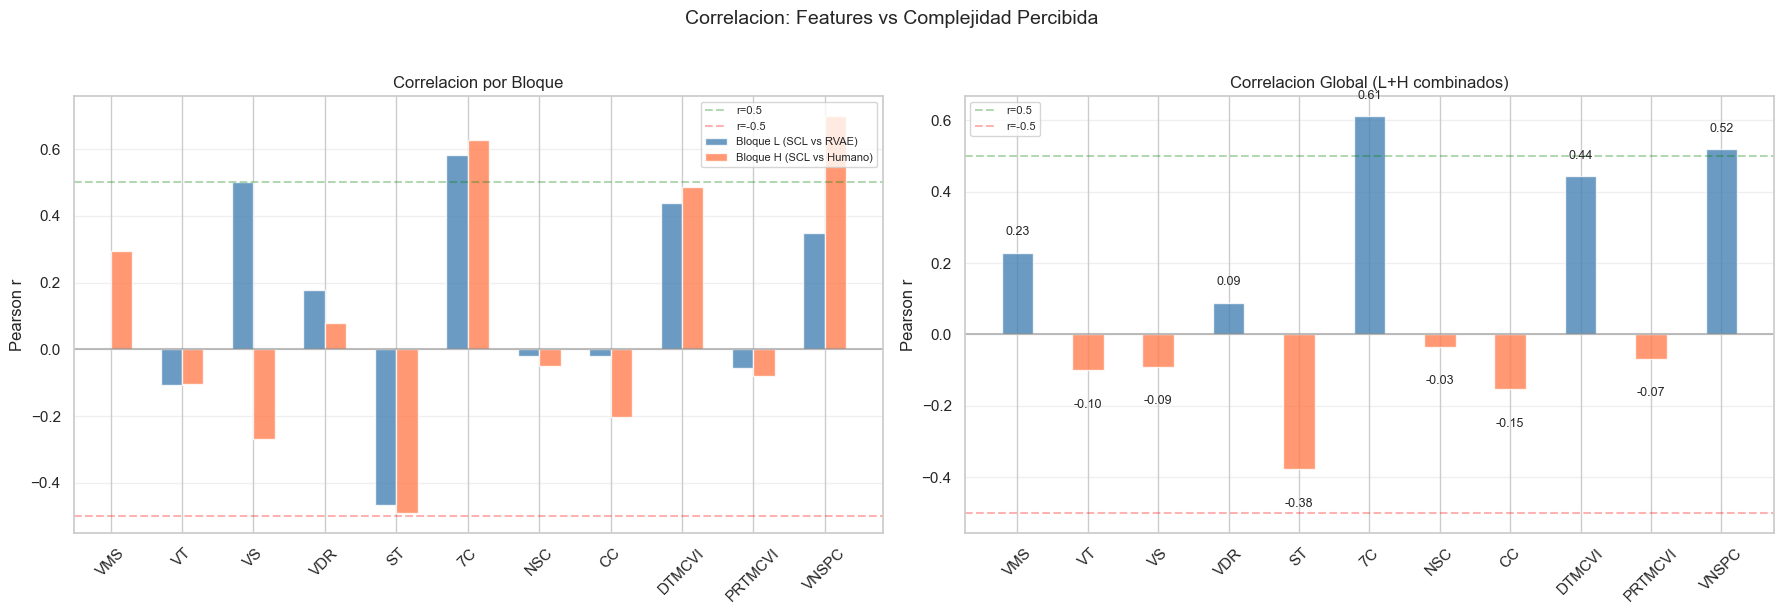

Correlacion global (L+H combinados):
Feature         r
VMS         0.229
VT         -0.100
VS         -0.091
VDR         0.089
ST         -0.378
7C          0.612
NSC        -0.034
CC         -0.154
DTMCVI      0.445
PRTMCVI    -0.068
VNSPC       0.520

Comparacion de correlaciones por bloque:
Feature    L (RVAE) H (Humano)
VMS             nan      0.294
VT           -0.106     -0.103
VS            0.501     -0.270
VDR           0.179      0.078
ST           -0.467     -0.490
7C            0.584      0.626
NSC          -0.020     -0.050
CC           -0.020     -0.202
DTMCVI        0.439      0.487
PRTMCVI      -0.055     -0.081
VNSPC         0.350      0.699


In [8]:
# Grafico combinado: correlaciones por bloque y global
from scipy import stats

# Correlaciones globales
global_r = {}
for f in fs:
    r, p = stats.pearsonr(df_feats[f], df_feats['compl'])
    global_r[f] = r

# Correlaciones por bloque
r_vals = {}
for blk in ('L', 'H'):
    sub = df_feats[df_feats['blk']==blk]
    if len(sub) < 3: continue
    r_vals[blk] = {}
    for f in fs:
        r, p = stats.pearsonr(sub[f], sub['compl'])
        r_vals[blk][f] = r

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(len(fs))
w = 0.3

# Subplot 1: L vs H
r_l = [r_vals.get('L', {}).get(f, 0) for f in fs]
r_h = [r_vals.get('H', {}).get(f, 0) for f in fs]
ax1.bar(x - w/2, r_l, w, label='Bloque L (SCL vs RVAE)', color='steelblue', alpha=0.8)
ax1.bar(x + w/2, r_h, w, label='Bloque H (SCL vs Humano)', color='coral', alpha=0.8)
ax1.axhline(0, color='gray', ls='-', alpha=0.5)
ax1.axhline(0.5, color='green', ls='--', alpha=0.3, label='r=0.5')
ax1.axhline(-0.5, color='red', ls='--', alpha=0.3, label='r=-0.5')
ax1.set_xticks(x)
ax1.set_xticklabels(fs, rotation=45)
ax1.set_ylabel('Pearson r')
ax1.set_title('Correlacion por Bloque')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: global (L+H combinados)
r_g = [global_r[f] for f in fs]
colors = ['steelblue' if v > 0 else 'coral' for v in r_g]
bars = ax2.bar(x, r_g, w*1.5, color=colors, alpha=0.8)
ax2.axhline(0, color='gray', ls='-', alpha=0.5)
ax2.axhline(0.5, color='green', ls='--', alpha=0.3, label='r=0.5')
ax2.axhline(-0.5, color='red', ls='--', alpha=0.3, label='r=-0.5')
for bar, val in zip(bars, r_g):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.04 if val>0 else -0.08),
             f'{val:.2f}', ha='center', va='bottom' if val>0 else 'top', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(fs, rotation=45)
ax2.set_ylabel('Pearson r')
ax2.set_title('Correlacion Global (L+H combinados)')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Correlacion: Features vs Complejidad Percibida', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tablas
print("Correlacion global (L+H combinados):")
print(f"{'Feature':8s} {'r':>8s}")
for f in fs:
    print(f"{f:8s} {global_r[f]:>8.3f}")
print()
print("Comparacion de correlaciones por bloque:")
print(f"{'Feature':8s} {'L (RVAE)':>10s} {'H (Humano)':>10s}")
for f in fs:
    rl = r_vals.get('L', {}).get(f, 0)
    rh = r_vals.get('H', {}).get(f, 0)
    print(f"{f:8s} {rl:>10.3f} {rh:>10.3f}")


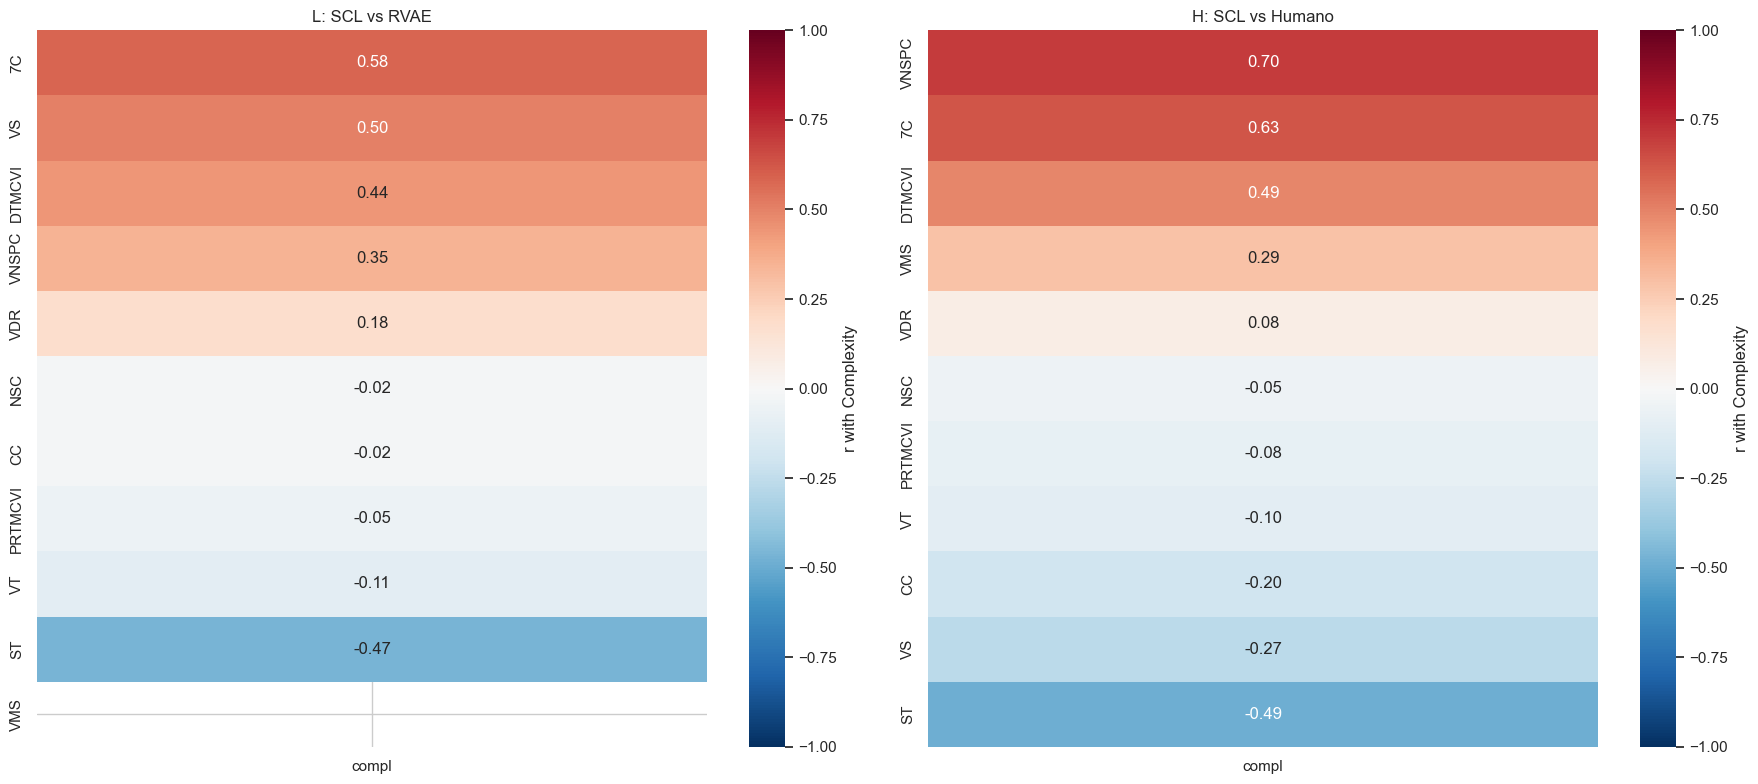

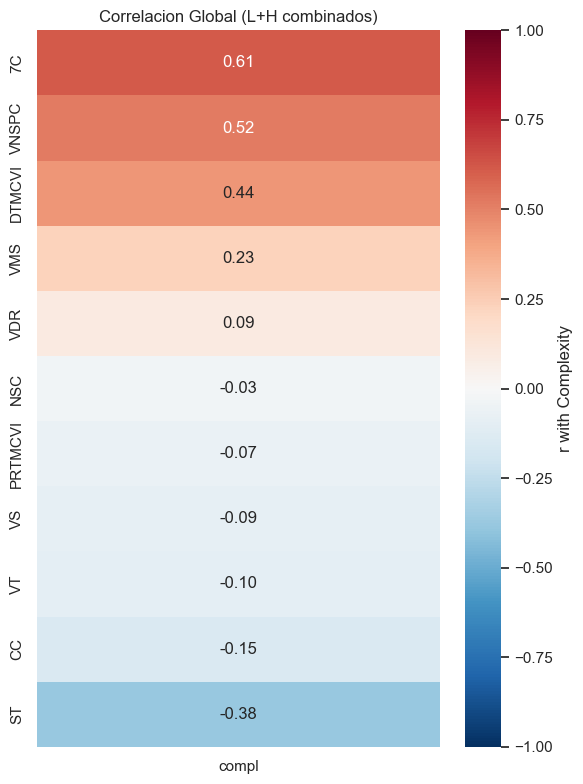

In [9]:
# Heatmap por bloque
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for idx, (blk, title) in enumerate([('L','L: SCL vs RVAE'),('H','H: SCL vs Humano')]):
    sub = df_feats[df_feats['blk']==blk]
    if len(sub)<3: continue
    cm = sub[['compl']+fs].corr()
    cc = cm[['compl']].drop('compl').sort_values('compl', ascending=False)
    ax = axes[idx]
    sns.heatmap(cc, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f', ax=ax,
                cbar_kws={'label':'r with Complexity'})
    ax.set_title(title); ax.set_ylabel('')
plt.tight_layout(); plt.show()


#Correlacion global (L+H combinados) heapmap
cm = df_feats[['compl']+fs].corr()
cc = cm[['compl']].drop('compl').sort_values('compl', ascending=False)
plt.figure(figsize=(6, 8))
sns.heatmap(cc, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f',
            cbar_kws={'label':'r with Complexity'})
plt.title('Correlacion Global (L+H combinados)'); plt.ylabel('')
plt.tight_layout(); plt.show()




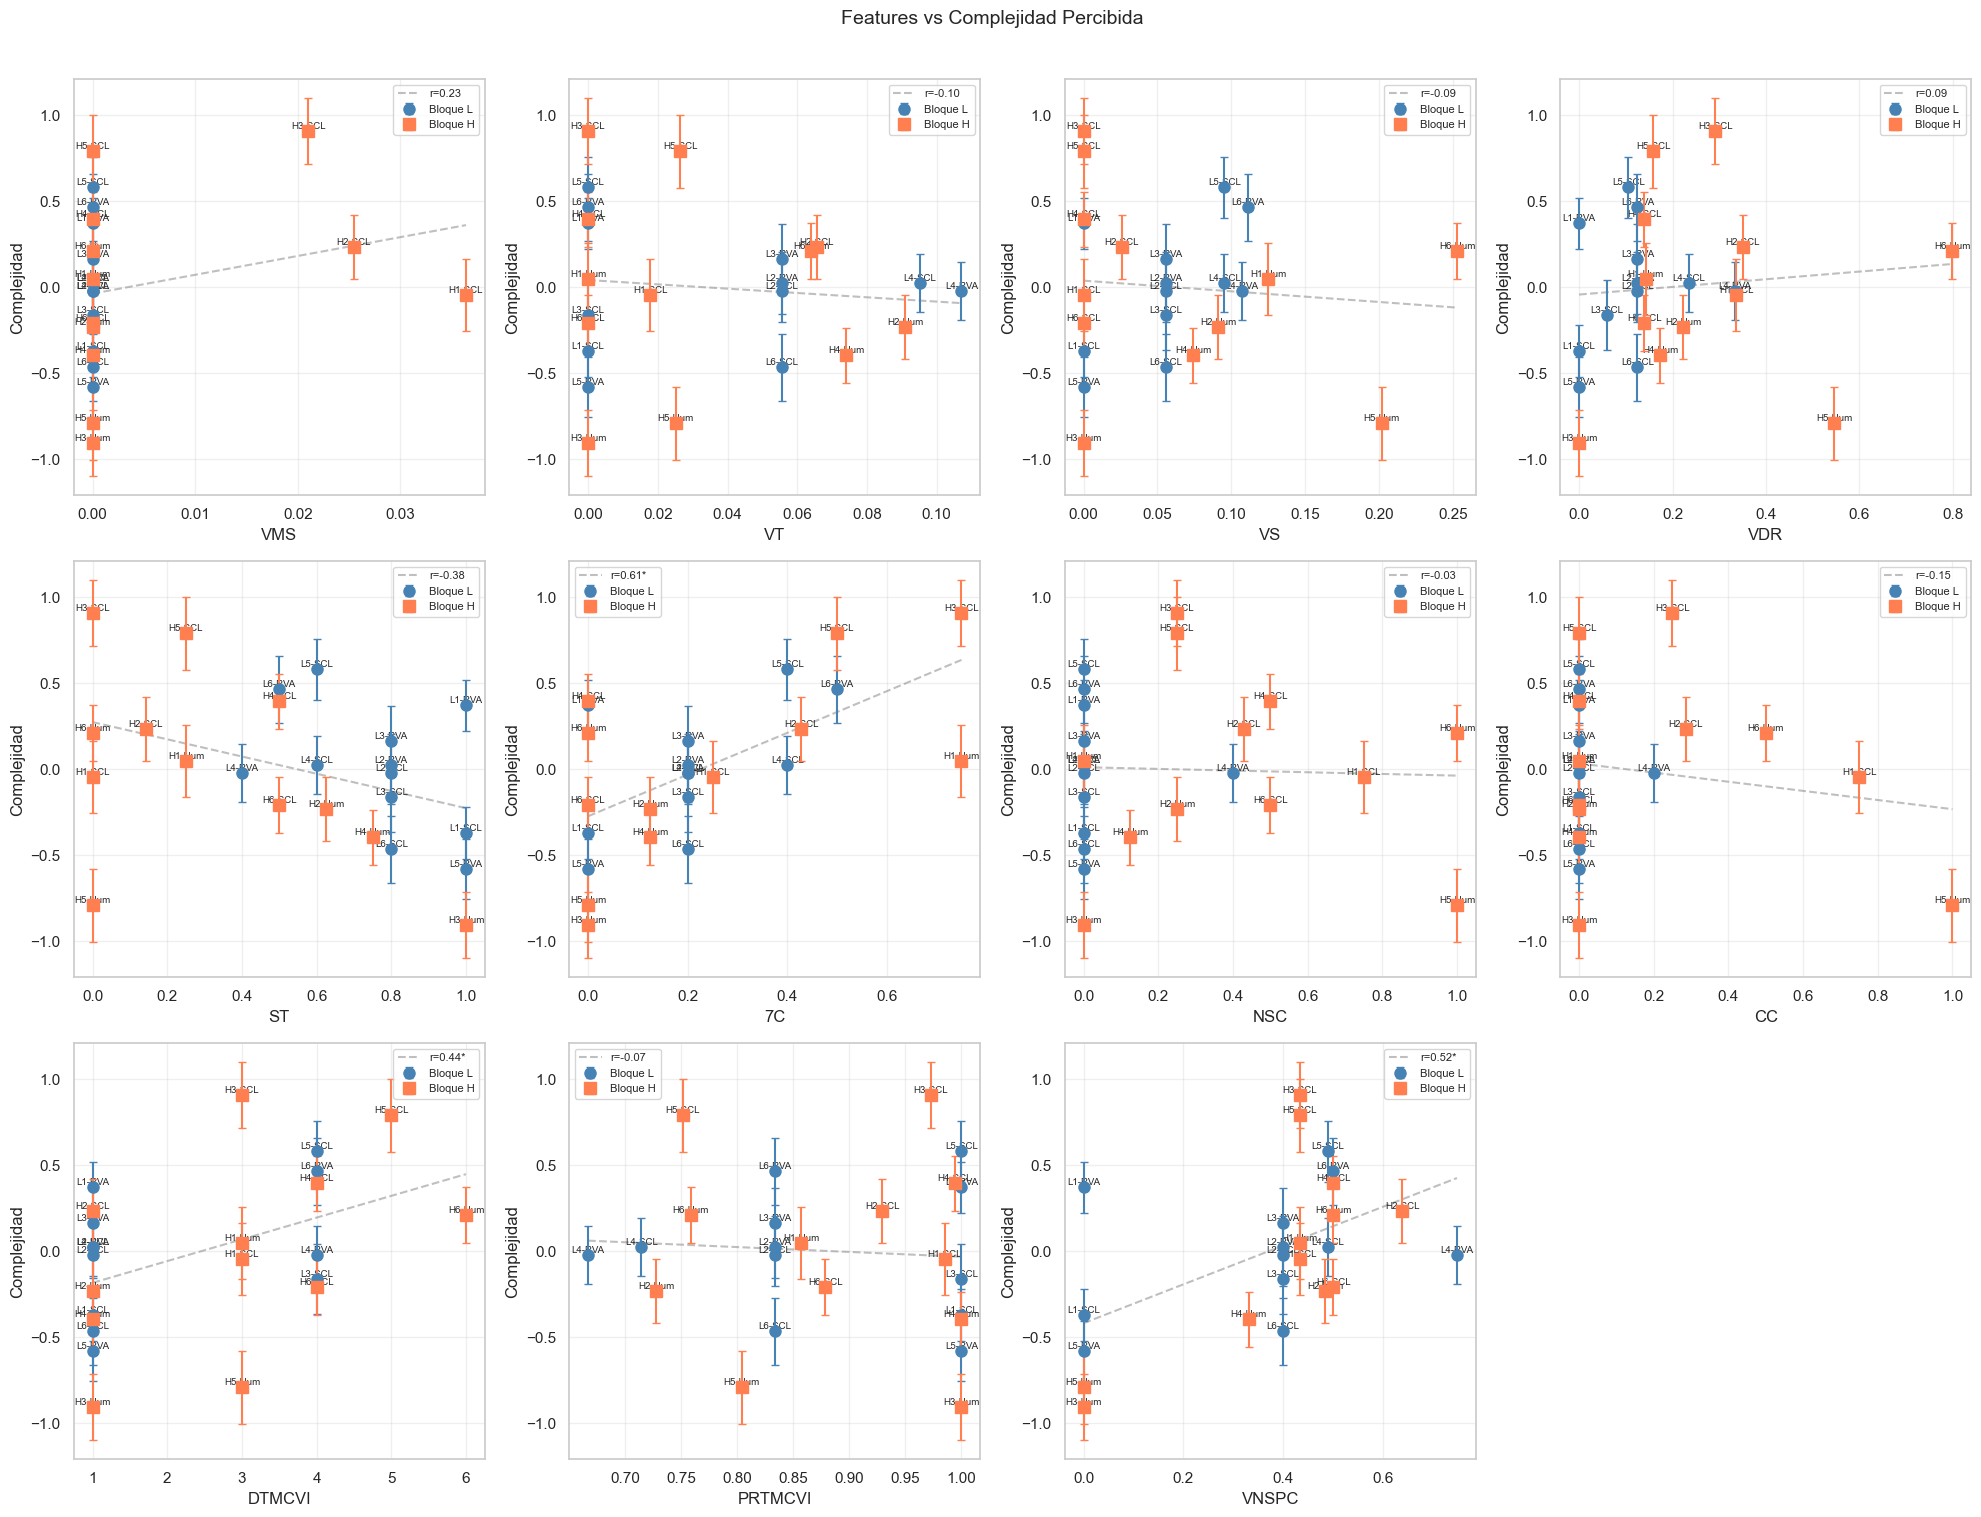

In [10]:
# Scatter
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for i,f in enumerate(fs):
    ax = axes[i]
    for blk,m,c in [('L','o','steelblue'),('H','s','coral')]:
        sub = df_feats[df_feats['blk']==blk]
        ax.errorbar(sub[f], sub['compl'], yerr=sub['compl_se'], fmt=m, color=c, capsize=3, ms=8, label=f'Bloque {blk}', zorder=5)
        for _,r in sub.iterrows():
            ax.annotate(f"{r['col']}-{r['audio'][:3]}", (r[f], r['compl']), fontsize=7, ha='center', va='bottom')
    sl,it,rv,pv,_ = stats.linregress(df_feats[f], df_feats['compl'])
    xl = np.linspace(df_feats[f].min(), df_feats[f].max(), 100)
    ax.plot(xl, it+sl*xl, 'gray', ls='--', alpha=0.5, label=f'r={rv:.2f}{"*" if pv<.05 else ""}')
    ax.set_xlabel(f); ax.set_ylabel('Complejidad'); ax.legend(fontsize=8); ax.grid(True, alpha=.3)
for j in range(len(fs),len(axes)): axes[j].set_visible(False)
plt.suptitle('Features vs Complejidad Percibida', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 6. Perfiles por tipo de audio

In [11]:
# Promedios por bloque y tipo
prof = df_feats.groupby(['blk','audio'])[fs+['compl']].agg(['mean','sem']).round(4)
print("Promedios por bloque y tipo:")
print(prof.to_string())

# Diferencia SCL - Ref
diff_rows = []
for blk,lref in [('L','RVAE'),('H','Humano')]:
    scl = df_feats[(df_feats['blk']==blk)&(df_feats['audio']=='SCL')]
    ref = df_feats[(df_feats['blk']==blk)&(df_feats['audio']==lref)]
    if len(scl)==0 or len(ref)==0: continue
    for f in fs:
        diff_rows.append({'blk':blk,'Feature':f,'SCL':round(scl[f].mean(),4),
                         'REF':round(ref[f].mean(),4),'diff':round(scl[f].mean()-ref[f].mean(),4)})
df_diff = pd.DataFrame(diff_rows)
print("Diferencias SCL vs Referencia:")
print(df_diff.to_string(index=False))


Promedios por bloque y tipo:
               VMS              VT              VS             VDR              ST              7C             NSC              CC          DTMCVI         PRTMCVI           VNSPC           compl        
              mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem    mean     sem
blk audio                                                                                                                                                                                                 
H   Humano  0.0000  0.0000  0.0424  0.0160  0.1240  0.0372  0.3140  0.1218  0.4375  0.1700  0.1667  0.1193  0.3958  0.1948  0.2500  0.1708  2.5000  0.8062  0.8577  0.0484  0.2913  0.0952 -0.3450  0.1817
    SCL     0.0138  0.0065  0.0183  0.0105  0.0043  0.0043  0.2360  0.0410  0.2322  0.0930  0.3214  0.1209  0.4464  0.0765  0.2143  0.1199  3.3333  0.5578  0.9

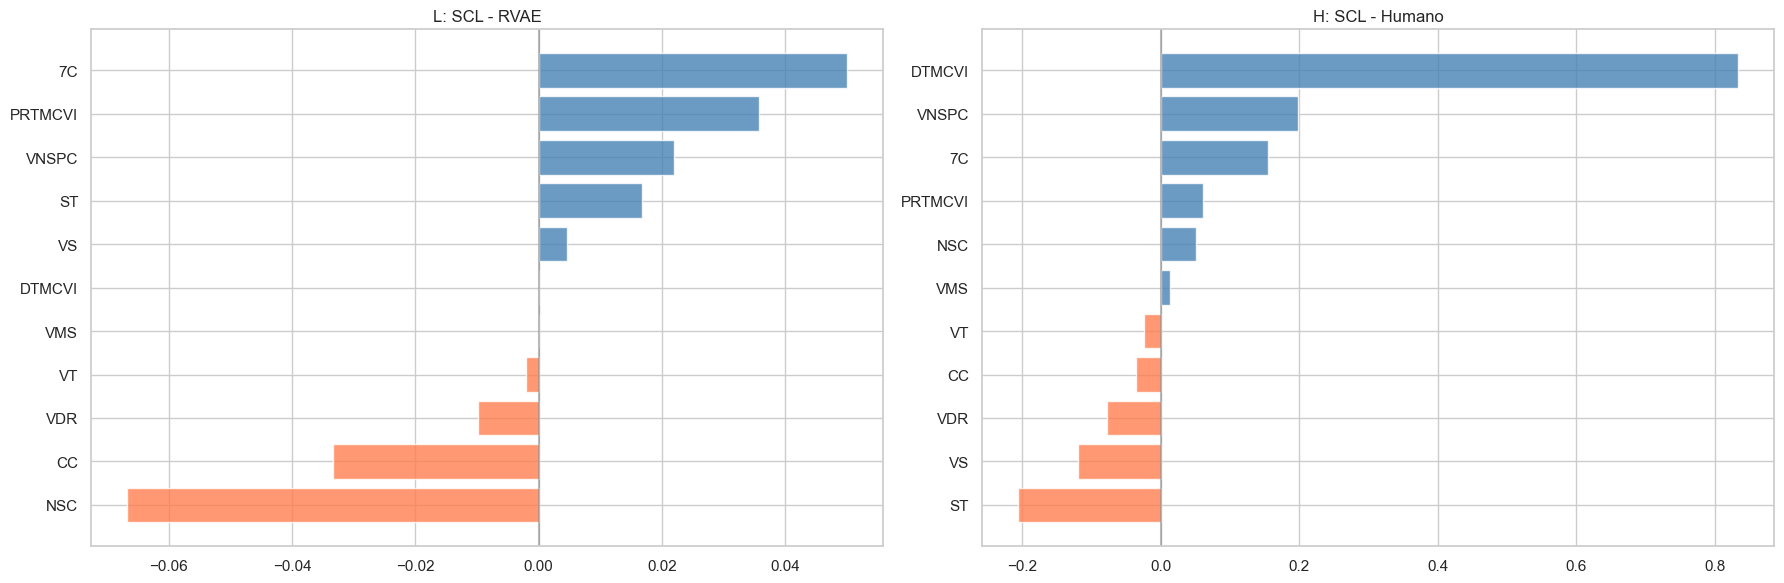

In [12]:
# Barplot diferencias
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for idx,(blk,lref) in enumerate([('L','RVAE'),('H','Humano')]):
    sub = df_diff[df_diff['blk']==blk].sort_values('diff')
    ax = axes[idx]
    cols = ['steelblue' if d>0 else 'coral' for d in sub['diff']]
    ax.barh(sub['Feature'], sub['diff'], color=cols, alpha=0.8)
    ax.axvline(0, color='gray', alpha=0.5)
    ax.set_title(f'{blk}: SCL - {lref}')
plt.tight_layout(); plt.show()


## 7. Audios mas y menos complejos

In [13]:
top = df_feats.nlargest(3, 'compl')
bot = df_feats.nsmallest(3, 'compl')
print("MAS complejos:")
for _,r in top.iterrows():
    print(f"  {r['col']}-{r['audio']}: compl={r['compl']:.3f}")
    for f in fs: print(f"    {f}: {r[f]:.4f}")
print()
print("MENOS complejos:")
for _,r in bot.iterrows():
    print(f"  {r['col']}-{r['audio']}: compl={r['compl']:.3f}")
    for f in fs: print(f"    {f}: {r[f]:.4f}")


MAS complejos:
  H3-SCL: compl=0.907
    VMS: 0.0210
    VT: 0.0000
    VS: 0.0000
    VDR: 0.2912
    ST: 0.0000
    7C: 0.7500
    NSC: 0.2500
    CC: 0.2500
    DTMCVI: 3.0000
    PRTMCVI: 0.9725
    VNSPC: 0.4331
  H5-SCL: compl=0.791
    VMS: 0.0000
    VT: 0.0265
    VS: 0.0000
    VDR: 0.1589
    ST: 0.2500
    7C: 0.5000
    NSC: 0.2500
    CC: 0.0000
    DTMCVI: 5.0000
    PRTMCVI: 0.7514
    VNSPC: 0.4331
  L5-SCL: compl=0.581
    VMS: 0.0000
    VT: 0.0000
    VS: 0.0952
    VDR: 0.1053
    ST: 0.6000
    7C: 0.4000
    NSC: 0.0000
    CC: 0.0000
    DTMCVI: 4.0000
    PRTMCVI: 1.0000
    VNSPC: 0.4900

MENOS complejos:
  H3-Humano: compl=-0.907
    VMS: 0.0000
    VT: 0.0000
    VS: 0.0000
    VDR: 0.0000
    ST: 1.0000
    7C: 0.0000
    NSC: 0.0000
    CC: 0.0000
    DTMCVI: 1.0000
    PRTMCVI: 1.0000
    VNSPC: 0.0000
  H5-Humano: compl=-0.791
    VMS: 0.0000
    VT: 0.0251
    VS: 0.2016
    VDR: 0.5461
    ST: 0.0000
    7C: 0.0000
    NSC: 1.0000
    CC: 1.0000
    DT

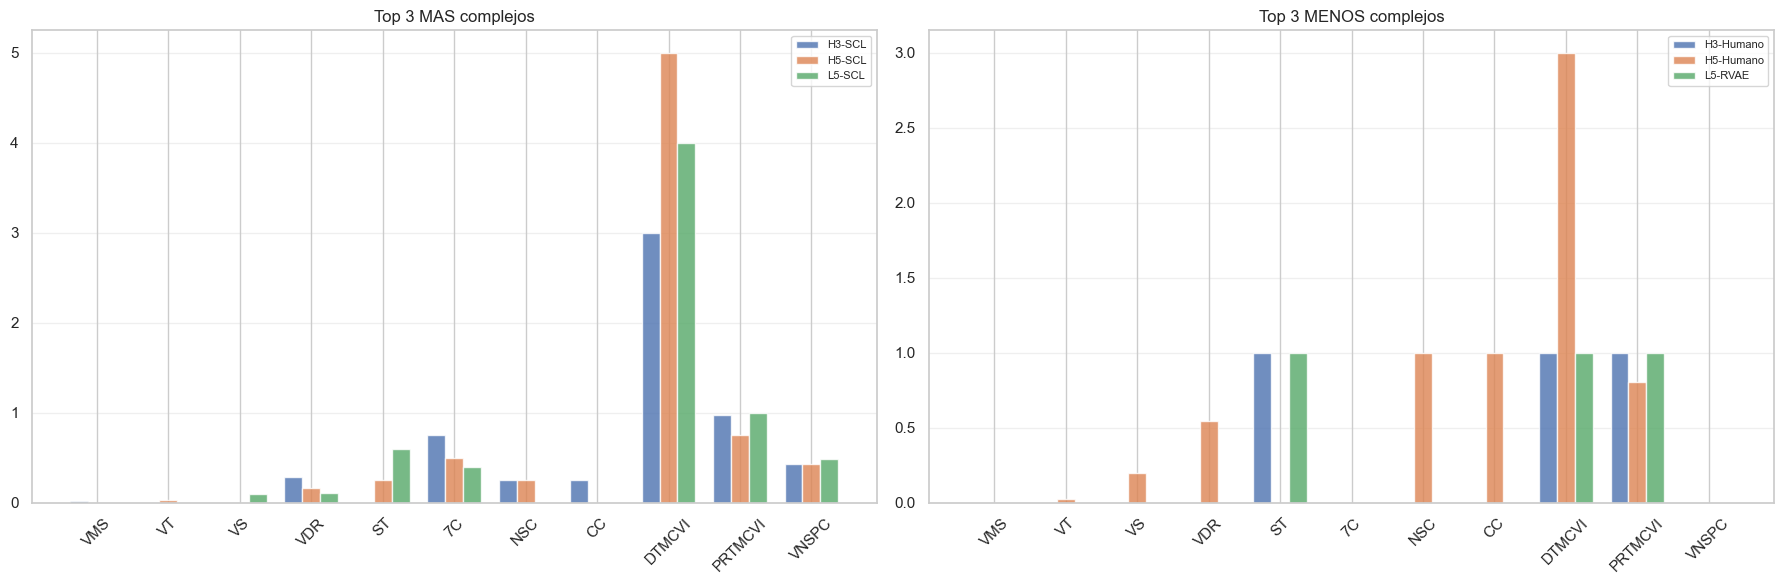

In [14]:
# Perfil visual
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for idx,(data,title) in enumerate([(top,'Top 3 MAS complejos'),(bot,'Top 3 MENOS complejos')]):
    ax = axes[idx]
    x = np.arange(len(fs)); w = 0.25
    for j,(_,r) in enumerate(data.iterrows()):
        ax.bar(x+(j-1)*w, [r[f] for f in fs], w, label=f"{r['col']}-{r['audio']}", alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(fs, rotation=45)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()


## 8. Hallazgos principales

In [15]:
print("="*60)
print("HALLAZGOS PRINCIPALES")
print("="*60)
print()
print("--- Features que mejor predicen complejidad percibida ---")
sig = corr_df[corr_df['sig']=='*'].sort_values('r', ascending=False)
if len(sig)>0:
    for _,r in sig.iterrows():
        print(f"  {r['Feature']:8s}: r={r['r']:.3f}, p={r['p']:.4f} **")
else:
    print("  Ninguna significativa globalmente")
print()
print("Top 3 por |r|:")
for _,r in corr_df.sort_values('r', key=abs, ascending=False).head(3).iterrows():
    print(f"  {r['Feature']:8s}: r={r['r']:.3f}, p={r['p']:.4f} {r['sig']}")
print()
print("--- Diferencias SCL vs Referencia ---")
for blk,lbl in [('L','RVAE'),('H','Humano')]:
    print(f"  Bloque {blk} (SCL vs {lbl}):")
    for _,r in df_diff[df_diff['blk']==blk].sort_values('diff', key=abs, ascending=False).head(3).iterrows():
        print(f"    {r['Feature']}: SCL={r['SCL']:.3f}, {lbl}={r['REF']:.3f}, diff={r['diff']:+.4f}")
print()
print("--- Divergencia entre bloques ---")
div = df_diff.groupby('Feature')['diff'].agg(lambda x: abs(x.iloc[1]-x.iloc[0]) if len(x)>1 else 0)
for feat, val in div.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {val:.4f}")
print()
print("--- Resumen ---")
for blk in ['L','H']:
    sub = df_feats[df_feats['blk']==blk]
    s = sub[sub['audio']=='SCL']['compl'].mean()
    rl = 'RVAE' if blk=='L' else 'Humano'
    r = sub[sub['audio']==rl]['compl'].mean()
    print(f"  Bloque {blk}: SCL={s:.3f}, {rl}={r:.3f}, diff={s-r:+.3f}")


HALLAZGOS PRINCIPALES

--- Features que mejor predicen complejidad percibida ---
  7C      : r=0.612, p=0.0015 **
  VNSPC   : r=0.520, p=0.0092 **
  DTMCVI  : r=0.445, p=0.0295 **

Top 3 por |r|:
  7C      : r=0.612, p=0.0015 *
  VNSPC   : r=0.520, p=0.0092 *
  DTMCVI  : r=0.445, p=0.0295 *

--- Diferencias SCL vs Referencia ---
  Bloque L (SCL vs RVAE):
    NSC: SCL=0.000, RVAE=0.067, diff=-0.0667
    7C: SCL=0.233, RVAE=0.183, diff=+0.0500
    PRTMCVI: SCL=0.897, RVAE=0.861, diff=+0.0357
  Bloque H (SCL vs Humano):
    DTMCVI: SCL=3.333, Humano=2.500, diff=+0.8333
    ST: SCL=0.232, Humano=0.438, diff=-0.2054
    VNSPC: SCL=0.490, Humano=0.291, diff=+0.1984

--- Divergencia entre bloques ---
  DTMCVI: 0.8333
  ST: 0.2221
  VNSPC: 0.1765

--- Resumen ---
  Bloque L: SCL=-0.070, RVAE=0.070, diff=-0.140
  Bloque H: SCL=0.345, Humano=-0.345, diff=+0.690
